In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm 

%run 01_vqvae.ipynb
%run 03_transformer.ipynb

input:  torch.Size([4, 1, 28, 28])
x_hat: torch.Size([4, 1, 28, 28])
z_e: torch.Size([4, 32, 7, 7])
z_q: torch.Size([4, 32, 7, 7])
idx: torch.Size([4, 7, 7])
using mps
torch.Size([4, 49, 512])


## Encode Dataset

Run the frozen VQ-VAE encoder once over all of MNIST, save token sequences of shape `(60000, 50)` — label followed by 49 codebook indices.

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

vqvae = VQVAE(K=512, d=32).to(device)
vqvae.load_state_dict(torch.load('../data/vqvae_mnist.pt', map_location=device))
vqvae.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset    = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)

all_seqs = []
with torch.no_grad():
    for x, labels in tqdm(dataloader):
        x      = x.to(device)
        _, _, _, idx = vqvae(x)          # idx: (B, 7, 7)
        idx    = idx.view(x.shape[0], -1).cpu()  # (B, 49)
        labels = labels.unsqueeze(1)     # (B, 1)
        seq    = torch.cat([labels, idx], dim=1)  # (B, 50)
        all_seqs.append(seq)

all_seqs = torch.cat(all_seqs, dim=0)   # (60000, 50)
torch.save(all_seqs, '../data/mnist_tokens.pt')
print(f'saved: {all_seqs.shape}')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:02<00:00, 78.80it/s]

saved: torch.Size([60000, 50])


## Training

In [3]:
all_seqs   = torch.load('../data/mnist_tokens.pt')
token_dataset  = torch.utils.data.TensorDataset(all_seqs)
token_loader   = torch.utils.data.DataLoader(token_dataset, batch_size=128, shuffle=True)

epoch  1  loss 2.8668


epoch  2  loss 1.8483


epoch  3  loss 1.6687


epoch  4  loss 1.5956


epoch  5  loss 1.5526


...

epoch 26  loss 1.3595


epoch 27  loss 1.3562


epoch 28  loss 1.3527


epoch 29  loss 1.3490


epoch 30  loss 1.3455


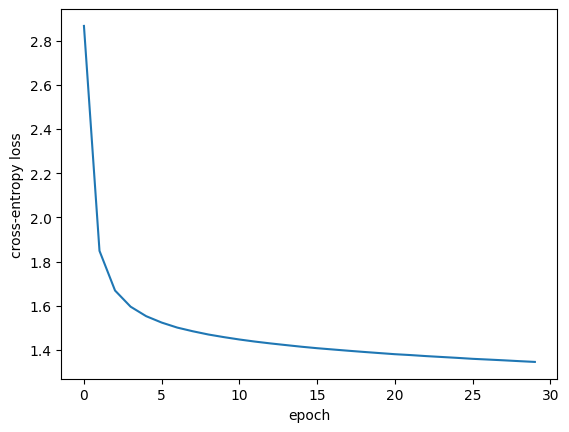

In [7]:
gpt       = GPT(K=512, S=7, d_model=128, nhead=4, num_layers=6).to(device)
optimizer = torch.optim.Adam(gpt.parameters(), lr=3e-4)
loss_fn   = nn.CrossEntropyLoss()

epochs = 30
losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    pbar = tqdm(token_loader, desc=f'epoch {epoch+1}/{epochs}', leave=False)
    for (seq,) in pbar:
        seq    = seq.to(device)          # (B, 50)
        inp    = seq[:, :-1]             # (B, 49) — input: label + first 48 tokens
        target = seq[:, 1:]             # (B, 49) — target: first 49 tokens

        logits = gpt(inp)               # (B, 49, K)
        # CrossEntropyLoss expects (B, K, S)
        loss   = loss_fn(logits.transpose(1, 2), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg = epoch_loss / len(token_loader)
    losses.append(avg)
    print(f'epoch {epoch+1:2d}  loss {avg:.4f}')

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('cross-entropy loss')
plt.show()

In [8]:
torch.save(gpt.cpu().state_dict(), '../data/gpt_mnist.pt')
gpt.to(device)

GPT(
  (token_emb): Embedding(512, 128)
  (label_emb): Embedding(10, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (linear): Linear(in_features=128, out_features=512, bias=True)
)